In [1]:
# ==============================================
# QUESTION 2: DIGITS DATASET (OCR)
# SVM and Logistic Regression Classifiers
# ==============================================

# 1. Import the various libraries (3 Marks)
# ------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# 2. Import the Dataset (3 Marks)
# --------------------------------
digits = load_digits()
X = digits.data          # feature matrix (1797 samples, 64 features)
y = digits.target        # target labels (0-9)

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")

Dataset shape: (1797, 64)
Number of classes: 10


In [3]:
# 3. Split the Dataset in 85% for training (3 Marks)
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.15,      # 15% test, 85% train
    random_state=42,
    stratify=y           # maintain class distribution
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 1527
Test set size: 270


In [4]:
# ==============================================
# 4. SVM Classifier (12 Marks total)
# ==============================================

# 4a. Import and initiate it (3 Marks)
# -------------------------------------
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# 4b. Train the Model (3 Marks)
# ------------------------------
svm_clf.fit(X_train, y_train)

# 4c. Evaluate the Score (3 Marks)
# ---------------------------------
svm_train_score = svm_clf.score(X_train, y_train)
svm_test_score = svm_clf.score(X_test, y_test)
print(f"\nSVM Training Accuracy: {svm_train_score:.4f}")
print(f"SVM Test Accuracy: {svm_test_score:.4f}")

# 4d. Predict the corresponding values for the Test set (3 Marks)
# ----------------------------------------------------------------
svm_predictions = svm_clf.predict(X_test)
print(f"SVM Predictions (first 10): {svm_predictions[:10]}")


SVM Training Accuracy: 0.9980
SVM Test Accuracy: 0.9889
SVM Predictions (first 10): [6 3 7 5 5 0 3 5 2 7]


In [6]:
# ==============================================
# 5. Logistic Regression Classifier (12 Marks total)
# ==============================================

# 5a. Import and initiate it (3 Marks)
# -------------------------------------
lr_clf = LogisticRegression(
    max_iter=1000, 
    C=1.0, 
    # multi_class='multinomial', 
    solver='lbfgs',
    random_state=42
)

# 5b. Train the Model (3 Marks)
# ------------------------------
lr_clf.fit(X_train, y_train)

# 5c. Evaluate the Score (3 Marks)
# ---------------------------------
lr_train_score = lr_clf.score(X_train, y_train)
lr_test_score = lr_clf.score(X_test, y_test)
print(f"\nLogistic Regression Training Accuracy: {lr_train_score:.4f}")
print(f"Logistic Regression Test Accuracy: {lr_test_score:.4f}")

# 5d. Predict the corresponding values for the Test set (3 Marks)
# ----------------------------------------------------------------
lr_predictions = lr_clf.predict(X_test)
print(f"Logistic Regression Predictions (first 10): {lr_predictions[:10]}")


Logistic Regression Training Accuracy: 1.0000
Logistic Regression Test Accuracy: 0.9556
Logistic Regression Predictions (first 10): [6 3 7 5 5 0 3 5 2 7]


In [7]:
# ==============================================
# 6. Import CROSSVALIDATION module and pass in Logistic Regression (3 Marks)
# ==============================================
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on Logistic Regression
cv_scores = cross_val_score(lr_clf, X_train, y_train, cv=5, scoring='accuracy')
print(f"\nCross-Validation Scores (Logistic Regression): {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Cross-Validation Scores (Logistic Regression): [0.97385621 0.95098039 0.96721311 0.9442623  0.96721311]
Mean CV Score: 0.9607 (+/- 0.0223)


In [8]:
# ==============================================
# 7. Generate the Confusion Matrix (3 Marks)
# ==============================================
# Using SVM predictions (or Logistic Regression)
cm = confusion_matrix(y_test, svm_predictions)
print("\nConfusion Matrix (SVM):")
print(cm)


Confusion Matrix (SVM):
[[27  0  0  0  0  0  0  0  0  0]
 [ 0 27  0  0  0  0  0  0  0  0]
 [ 0  0 27  0  0  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0]
 [ 0  0  0  0  0 27  0  0  0  0]
 [ 0  0  0  0  0  0 27  0  0  0]
 [ 0  0  0  0  0  0  0 27  0  0]
 [ 0  2  0  0  0  0  0  0 24  0]
 [ 0  0  0  0  0  0  0  1  0 26]]


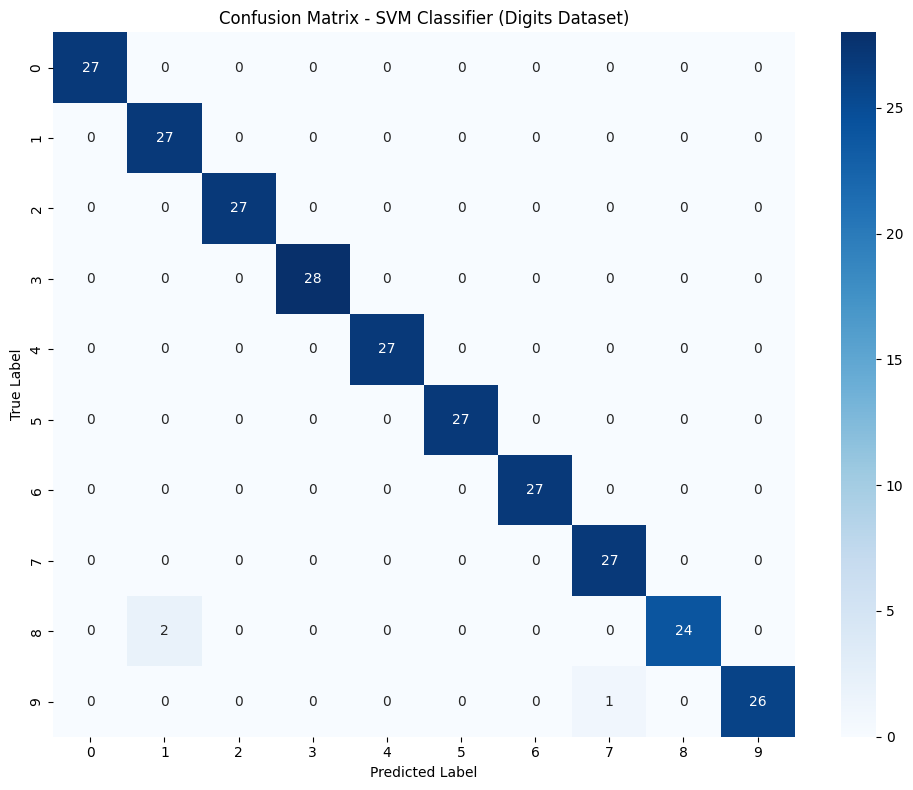

In [9]:
# ==============================================
# 8. Plot Confusion Matrix with Heatmap using Seaborn (3 Marks)
# ==============================================
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=digits.target_names,
    yticklabels=digits.target_names
)
plt.title('Confusion Matrix - SVM Classifier (Digits Dataset)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()